<hr/>

# Miscellaneous Topics
By: **Donovan Vincent Jr** - dvincen9@jh.edu <br/>
Estimated Workthrough Time: **30 mins**

<hr/>

<h1><font color="darkred">Normalized Discounted Cumulative Gain at K [NDCG@K]</font></h1>

---
> Why use NDCG@K?

Normalized Discounted Cumulative Gain at k [NDCG@K] is a generalized scoring metric from [0,1] that provides insight into the `quality of ranking` achieved by a model. NDCG@K measures how much your model "front-loads the good stuff" compared to a perfect ranking. It was first introduced in [2002 by Järvelin and Kekäläinen](https://dl.acm.org/doi/10.1145/582415.582418) and quickly became a foundational method in information retrieval.

--- 

> Terms: 
* `Gain`= (a.k.a. relevance, utility, grade, etc.) the ranking order determined by the model
* `Cumulative` = sum all of them together 
* `Discounting` = "reduce" the score by division (typically by $\frac{1}{log_2(i+1)}$, but all logs are equivalent)
* `Normalized` = divide it by the "ideal" scenario (if the model ranked everything perfectly) ($\frac{DCG@K}{iDCG@K}$)
* `Ideal`: The true rank values that the models are trying to replicate
--- 


> Algorithm
1. Use the `PREDICTED RANKINGS` to order the `TRUE SCORES` $\implies$ use this to calculate <font color='red'>DCG</font> 
2. Use the `TRUE RANKINGS` to order the `TRUE SCORES` $\implies$ use this to calculate <font color='red'>iDCG</font> 
3. Divide the 2 to get <font color='red'>NDCG</font> 
--- 

In [320]:
import scipy
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Logs detour

Before going into the code, I would like to `explain a trick` I said earlier that I believe deserves a brief explanation. If you are proficient in logs, feel free to skip this section, but I still think a quick glance through the review is helpful at all levels. 


> Log change of base formula

Let's say we want to calculate the value of a logarithm, but the <font color='red'>current base is inefficient</font>. It would be much easier if we could jump to some new base (n).

* Given a base (b), a power (p), and a constant (c): 
    * $b^p = c$ [<font color='red'> Eq 1a </font>]
* This is equivalent (by definition) to:
    * $p=log_b(c)$ [<font color='red'> Eq 1b </font>]
* We can get to a new base (n) from the Eq 1a by: 
    * $log_n(b^p) = log_n(c) \implies  plog_n(b) = log_n(x) \implies p = \frac{log_n(x)}{log_n(a)}$ 
* But wait... earlier in Eq 1b we said $p=log_b(c)$ so:

<div align="center">

$$
p = log_b(c) = \frac{log_n(c)}{log_n(b)}
$$

</div>


> All logs are equivalent

This formula is partly where we get the heuristic: "all logs are equivalent" [<font color='red'> NOT EQUAL </font> ]

* Notice in $log_b(c) = \frac{log_n(c)}{log_n(b)}$, that the denominator will just be some constant, $\gamma$
* Rewrite as $log_b(c) = \gamma log_n(c)$
* Since these are equivalent, it doesn't matter what base I use! Just use the one that's easiest

Intuition: "<font color='purple'>If I have some number c, whether I take</font> $log_b$ or $log_n$ <font color='purple'>, all values are proportional by </font> $\gamma$"


# NDCG@K Hand Example

Imagine a race between you and 3 friends. Before racing, you write down the order you believe everyone will finish in on a sheet of paper and leave it at the finish line. After the race is done, you see that it isn't EXACTLY what you expected. Let's `score the quality of your guess`

> 0. Problem set up
* Let $s_t = [1, 2, 3, 4]$ be the true scores
* Let $s_p = [1, 2, 4, 3]$ be the predicted scores

> 1. Calculate DCG@4

* Order the <font color='red'>TRUE</font> list by <font color='red'>your ranking index</font> (descending order)
    * $o_p = [2, 3, 1, 0]$ (What 0th index to look at to find the numbers in decreasing order e.g. <font color='purple'>The number 4 is at position 2 in </font>$s_p$)
    * $s_t^{DCG} = [3, 4, 2, 1]$ (Reorder the true values by the indices in o_p)

* Sum across $s_t^{DCG}$ to find the DISCOUNTED CUMULATIVE GAIN
    * $DCG(s) = \sum_{i=1}^4 \frac{s_i}{log_2(i+1)}$
    * $DCG(s_t^{DCG}) = \frac{3}{log_2(2)} + \frac{4}{log_2(3)} + \frac{2}{log_2(4)} + \frac{1}{log_2(5)} = 3 + 2.524 + 1 + 0.431 = 6.955$


> 2. Calculate iDCG@4

* Order the <font color='red'>TRUE</font> list by the <font color='red'>true ranking index</font> (descending order)
    * $o_t = [3, 2, 1, 0]$ (What 0th index to look at to find the numbers in decreasing order)
    * $s_t^{iDCG} = [4, 3, 2, 1]$ (Reorder the true values by the indices in o_p)

* Sum across $s_t^{DCG}$ to find the DISCOUNTED CUMULATIVE GAIN
    * $DCG(s) = \sum_{i=1}^4 \frac{s_i}{log_2(i+1)}$
    * $DCG(s_t^{iDCG}) = \frac{4}{log_2(2)} + \frac{3}{log_2(3)} + \frac{2}{log_2(4)} + \frac{1}{log_2(5)} = 4 + 1.90 + 1 + 0.431 = 7.331$


> 3. Calculate NDCG@4

* $NDCG = \frac{DCG}{iDCG} = \frac{6.955}{7.331} = 0.949$ (Not too bad!)


> You're friend did worse

* Lets say you're friend had the list completely reversed: $s_n = [4,3,2,1]$. What will his score be?
    * Ans: 0.75


> Key take aways!
* As $n \to \infty \implies log_2(n) \to \infty \implies \frac{constant}{log_2(n)} \to 0$
    * The discount term `penalizes` early, but drops off logarithmicly for later values
    * Errors away from the first few positions have marginal contribute to the DCG, thus small contributions to the NDCG

# NDCG@K Basketball Example

Let's imagine you and some friends were watching the `Lakers vs OKC` game on February 7th 2023 as LeBron passed Kareem Abdul-Jabbar as the all time leading scorer. After a quick hoorah, one friend argues that Michael Jordan is still a better player overall. To settle the debate, you and a friend decide to rank the top 5 all-time scorers in the order of who you believe score the most points.

In [321]:
nba_players = {
    "LeBron": 1,
    "Kareem": 2,
    "Malone": 3,
    "Kobe": 4,
    "Jordan": 5,
}

your_list = ["LeBron", "Kareem", "Jordan", "Kobe", "Malone"]
friendA = ["LeBron", "Kareem", "Malone", "Jordan", "Kobe"]
friendB = ["LeBron", "Kareem", "Malone", "Kobe", "Jordan"]

your_list_int = [nba_players[i] for i in your_list]
friendA_int = [nba_players[i] for i in friendA]
friendB_int = [nba_players[i] for i in friendB]

# Note: All of these ranks have the same cumulative gain! (CG=15), this is why we must "discount" them


In [322]:
def NDCG_K_simple(predictions, labels, k=None):
    """
    predictions: These are PREDICTION scores
    labels: These are TRUE scores
    """
    if k is None:
        k = len(predictions)

    # Relevance = sort all scores in descending order to see how the model ranked the options
    prediction_order = np.argsort(predictions)[::-1]
    ideal_order = np.argsort(labels)[::-1]

    pred_order = np.array(labels)[prediction_order]
    ideal_order = np.array(labels)[ideal_order]

    # Discounted Cumulative Gain = sum across (CG), but introduce a penalty by position
    DCG, iDCG = 0, 0 
    for i in range(k): 
        DCG += pred_order[i] / np.log2(i+2) # Always +1 in formula, then i is 0-indexed
        iDCG += ideal_order[i] / np.log2(i+2)

    if iDCG ==0:
        return 0
    
    else:
        NDCG_K = DCG / iDCG
        return NDCG_K

In [323]:
labels = list(nba_players.values())

your_score = NDCG_K_simple(your_list_int, labels)
friendA_score = NDCG_K_simple(friendA_int, labels)
friendB_score = NDCG_K_simple(friendB_int, labels)

print(your_score)
print(friendA_score)
print(friendB_score)

# It's pretty clear to see who did best now without having to look back at the list :)

0.902647263675672
0.9640700016142872
1.0


# NDCG as a function of K

Now that we have an intuition on how to calculate NDCG@K, let's quickly look at how K affects NDCG. 

1. Clearly k can not be bigger than n <font color='red'>(k !> n)</font>, as k=n means we scored all rankings
2. As $k \to n$: <font color='red'>every item is included</font>, so NDCG = whole ranking score, so this flattens out
3. As $k \to 1$: we allow <font color='red'>less room for error</font>, so NDCG approaches low values

## Ranking scenario

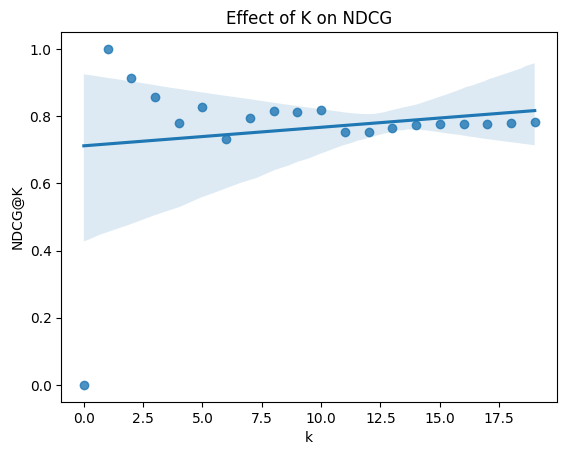

In [324]:
n = 20
seed = 3110
X = np.arange(0,n)

# Generate some random data labels
np.random.shuffle(X)
true_labels = X.copy()

np.random.shuffle(X)
predicted_labels = X.copy()

X = np.arange(0,n)
NDCG_VALUES = []
for i in range(n):
    value = NDCG_K_simple(predicted_labels[:i], true_labels[:i], i)
    NDCG_VALUES.append(value)


sns.regplot(x=np.arange(0,n), y=NDCG_VALUES)
plt.xlabel("k")
plt.ylabel("NDCG@K")
plt.title("Effect of K on NDCG")
plt.show()

## Binary decision scenario

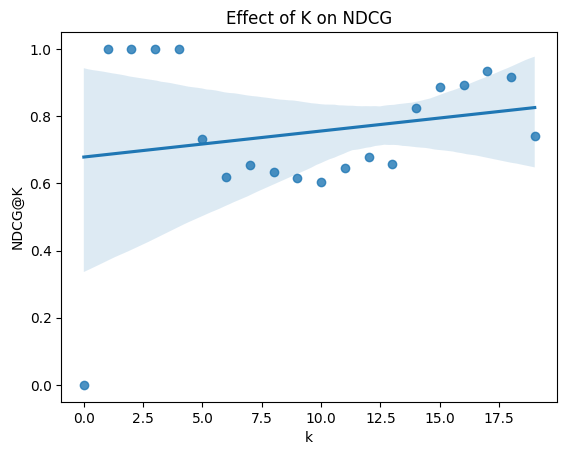

In [325]:
# Generate some random data labels
true_labels = scipy.stats.bernoulli.rvs(p=0.4, size=n, random_state=seed)
predicted_labels = scipy.stats.bernoulli.rvs(p=0.4, size=n, random_state=seed*2)

NDCG_VALUES = []
for i in range(n):
    value = NDCG_K_simple(predicted_labels[:i], true_labels[:i], i)
    NDCG_VALUES.append(value)


sns.regplot(x=np.arange(0,n), y=NDCG_VALUES)
plt.xlabel("k")
plt.ylabel("NDCG@K")
plt.title("Effect of K on NDCG")
plt.show()



# Manual implementation vs Sklearn

## Generalized manual implementation

In [326]:
import numpy as np

def dcg_at_k(relevance, k):
    """Compute DCG@k"""
    relevance = np.array(relevance)[:k]
    discounts = np.log2(np.arange(2, len(relevance) + 2))
    return np.sum(relevance / discounts)


def ndcg_at_k(y_true, y_pred, k):
    """
    y_true: true relevance scores (list)
    y_pred: predicted scores (same length)
    k: cutoff
    """
    # Sort by predicted scores (descending)
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.array(y_true)[order]

    # Compute DCG
    dcg = dcg_at_k(y_true_sorted, k)

    # Compute IDCG (ideal ranking)
    ideal_order = np.argsort(y_true)[::-1]
    y_true_ideal = np.array(y_true)[ideal_order]
    idcg = dcg_at_k(y_true_ideal, k)

    if idcg == 0:
        return 0.0

    return dcg / idcg


# Example from hand example from above
y_true = [1, 2, 3, 4]
y_pred = [1, 2, 4, 3]
print("Hand example NDCG@{}: {:.4f}".format(k, ndcg_at_k(y_true, y_pred, k)))

# Second example from the hand example above
y_true = [1, 2, 3, 4]
y_pred = [4, 3, 2, 1]
print("Friend example NDCG@{}: {:.4f}".format(k, ndcg_at_k(y_true, y_pred, k)))

Hand example NDCG@5: 0.9496
Friend example NDCG@5: 0.7489


## [NDCG@K in Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html)

In [327]:
from sklearn.metrics import ndcg_score

#help(ndcg_score)
y_true = np.array([[3, 2, 3, 0, 1]])
y_pred = np.array([[0.2, 0.1, 0.4, 0.05, 0.3]])

score = ndcg_score(y_true, y_pred)
print("NDCG@{}: {:.4f}".format(k, score))

NDCG@5: 0.9476


# Further References

1. [Huggingface:](https://huggingface.co/blog/charchits7/understanding-ndcgk-metric) Understnading NDCG@K
2. [Evidently AI:](https://www.evidentlyai.com/ranking-metrics/ndcg-metric) NDCG@K Explained
3. [DigitalSreeni](https://www.youtube.com/watch?v=IMvunY3LrQI&t=406s) NDCG